In [34]:
# Import Required Libraries

# Import necessary libraries for data analysis, visualization, and machine learning

import pandas as pd                # Used for data manipulation and analysis
import numpy as np                 # Used for numerical operations
import matplotlib.pyplot as plt   # Used for creating graphs
import seaborn as sns             # Used for better data visualization
# Import machine learning tools from sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Explanation:
# Here we import all the libraries needed for data handling, visualization, and building the churn prediction model.


In [35]:
# LOAD THE DATASET
# Load the dataset into a pandas DataFrame
import pandas
df = pd.read_csv('Churn_Modelling.csv')

# Display the first 5 rows of the dataset
df.head()

# Explanation:
# This step loads the bank customer dataset into Python so we can analyze and process it.



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [36]:
# Explore the Dataset
# Display information about the dataset such as columns and data types
df.info()

# Show statistical summary of numerical columns
df.describe()

# Check if there are any missing values in the dataset
df.isnull().sum()

# Explanation:
# This helps us understand the dataset structure, data types, and check for missing values before cleaning.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [37]:
# Remove Unnecessary Columns
# Drop columns that are not useful for prediction
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

# Display the first rows again
df.head()

# Explanation:
# These columns are identifiers and do not help the model predict customer churn.


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [38]:
# Remove Unnecessary Columns
# Drop columns that are not useful for prediction
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1, errors= 'ignore')

# Display the first rows again
df.head()

# Explanation:
# These columns are identifiers and do not help the model predict customer churn.


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [39]:
# Define Features and Target
# Features (Independent variables)
X = df.drop('Exited', axis=1)

# Target variable (Dependent variable)
# Exited = 1 means customer left the bank
# Exited = 0 means customer stayed
y = df['Exited']

# Explanation:
# We separate input features (X) and target variable (y).

In [40]:
# Split Dataset into Training and Testing Data
# Split dataset into 80% training data and 20% testing data
X = pd.get_dummies(X, drop_first=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Explanation:
#Training data is used to train the model, and testing data is used to check model performance.

In [41]:
# Train the Machine Learning Model
# Create Random Forest Classifier model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

# Train the model using training data
model.fit(X_train, y_train)

# Explanation:
# The model learns patterns in the data to predict which customers will leave the bank.



,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
# Make Predictions
# Use the trained model to predict churn on test data
y_pred = model.predict(X_test)

# Explanation:
# The model predicts whether customers in the test data will exit the bank or not.


In [43]:
# Evaluate Model Performance
# Calculate model accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Explanation:
# This shows how well the model performs in predicting customer churn.


Accuracy: 0.868
Confusion Matrix:
[[1550   57]
 [ 207  186]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.77      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.86      2000



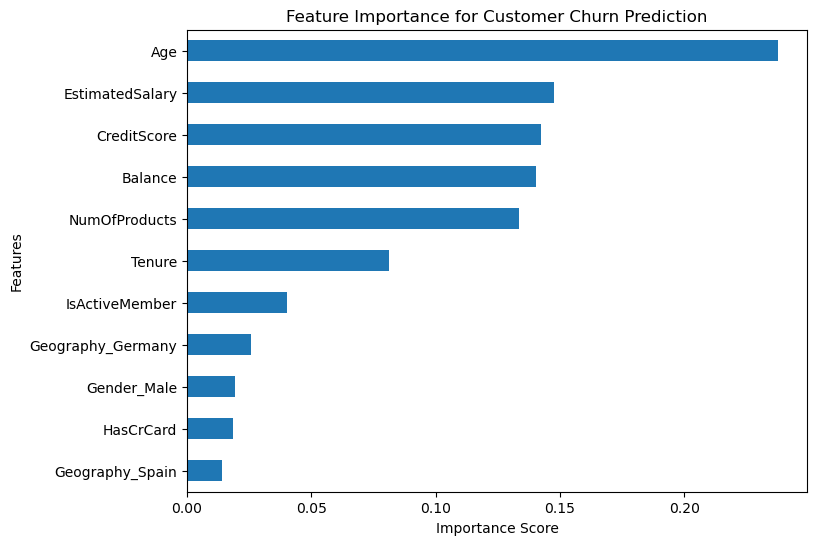

In [44]:
# Feature Importance Analysis
# Calculate feature importance from the trained model
importance = pd.Series(model.feature_importances_, index=X.columns)

# Plot feature importance
importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Feature Importance for Customer Churn Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

 # Explanation:
# This graph shows which factors most influence customers leaving the bank, such as age, balance, or credit score.


 Conclusion (Write in Markdown Cell)

Example you can write:

Conclusion

In this project, a customer churn prediction model was developed using the bank customer dataset. The dataset was cleaned and categorical variables such as gender and geography were encoded. A Random Forest classifier was used to train the model.

The model achieved good accuracy in predicting whether a customer will leave the bank. Feature importance analysis showed that factors such as age, balance, and number of products play an important role in customer churn.
